# M2 Deep Dive: Where Did Sentiment Beat Earnings?

M2 achieved the **best trading return (+30.2%)** despite having the worst AUC (0.447). This notebook investigates:

1. **Which specific events** did M2 get right that M0/M1 got wrong?
2. **What happened** on those earnings days? (news analysis)
3. **Why** did sentiment features help in those cases?
4. **Where did M2 fail** — and why?

In [1]:
import sqlite3
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11

conn = sqlite3.connect('../data/hackathon.db')

# Load all data
earnings = pd.read_sql('SELECT * FROM earnings', conn)
prices = pd.read_sql('SELECT * FROM daily_prices', conn)
articles = pd.read_sql('SELECT * FROM window_articles', conn)
daily_sent = pd.read_sql('SELECT * FROM daily_sentiment', conn)

prices['date'] = pd.to_datetime(prices['date'])
earnings['earnings_date'] = pd.to_datetime(earnings['earnings_date'])
articles['article_date'] = pd.to_datetime(articles['article_date'])
articles['earnings_date'] = pd.to_datetime(articles['earnings_date'])
daily_sent['date'] = pd.to_datetime(daily_sent['date'])

# Load ED-day news
ed_news = pd.read_csv('../data/news/ed_day_articles.csv')
print(f'ED-day articles loaded: {len(ed_news)}')

ED-day articles loaded: 563


## 1. Reproduce M0/M1/M2 Predictions Per Event

In [2]:
# Build features (same as notebook 02)
records = []
for _, evt in earnings.iterrows():
    tk, ed = evt['ticker'], evt['earnings_date']
    tk_p = prices[prices['ticker'] == tk].sort_values('date')
    post = tk_p[tk_p['date'] > ed].head(5)
    pre = tk_p[tk_p['date'] <= ed].tail(1)
    if len(post) < 5 or pre.empty: continue
    p0, p5 = pre['close'].values[0], post['close'].values[-1]
    ret_5d = (p5 - p0) / p0
    
    mask = (articles['ticker'] == tk) & (articles['earnings_date'] == ed)
    w = articles[mask]
    if len(w) < 3:
        sm = st = sd = np.nan
    else:
        sm = w['polarity'].mean()
        da = w.groupby('article_date')['polarity'].mean().sort_index()
        mid = len(da) // 2
        st = da.iloc[mid:].mean() - da.iloc[:mid].mean() if len(da) >= 2 else 0
        qs, qe = ed - pd.Timedelta(days=37), ed - pd.Timedelta(days=30)
        q = daily_sent[(daily_sent['ticker'] == tk) & (daily_sent['date'] >= qs) & (daily_sent['date'] <= qe)]
        sd = sm - q['sentiment'].mean() if len(q) >= 3 else np.nan
    
    records.append({
        'ticker': tk, 'earnings_date': ed, 'surprise_pct': evt['surprise_pct'],
        'ret_5d': ret_5d, 'target': 1 if ret_5d > 0 else 0,
        'sent_mean': sm, 'sent_trend': st, 'sent_delta': sd, 'news_volume': len(w),
    })

df = pd.DataFrame(records).sort_values('earnings_date').reset_index(drop=True)
df_m2 = df.dropna(subset=['sent_mean', 'sent_trend', 'sent_delta', 'news_volume']).reset_index(drop=True)

# Walk-forward predictions
MIN_TRAIN = 40
y = df_m2['target'].values
X_m1 = df_m2[['surprise_pct']].values
X_m2 = df_m2[['surprise_pct', 'sent_mean', 'sent_trend', 'sent_delta', 'news_volume']].values

event_results = []
for t in range(MIN_TRAIN, len(df_m2)):
    m1 = LogisticRegression(random_state=42, max_iter=1000)
    m1.fit(X_m1[:t], y[:t])
    sc = StandardScaler()
    Xtr = sc.fit_transform(X_m2[:t]); Xte = sc.transform(X_m2[t:t+1])
    m2 = LogisticRegression(random_state=42, max_iter=1000)
    m2.fit(Xtr, y[:t])
    
    row = df_m2.iloc[t]
    m0p = int(row['surprise_pct'] > 0)
    m1p = m1.predict(X_m1[t:t+1])[0]
    m2p = m2.predict(Xte)[0]
    
    event_results.append({
        'ticker': row['ticker'],
        'earnings_date': row['earnings_date'],
        'surprise_pct': row['surprise_pct'],
        'ret_5d_pct': row['ret_5d'] * 100,
        'target': y[t],
        'sent_mean': row['sent_mean'],
        'sent_trend': row['sent_trend'],
        'sent_delta': row['sent_delta'],
        'news_volume': row['news_volume'],
        'm0_pred': m0p, 'm1_pred': m1p, 'm2_pred': m2p,
        'm0_pnl': row['ret_5d'] if m0p == 1 else -row['ret_5d'],
        'm2_pnl': row['ret_5d'] if m2p == 1 else -row['ret_5d'],
    })

rdf = pd.DataFrame(event_results)
rdf['m0_correct'] = (rdf['m0_pred'] == rdf['target'])
rdf['m1_correct'] = (rdf['m1_pred'] == rdf['target'])
rdf['m2_correct'] = (rdf['m2_pred'] == rdf['target'])
rdf['m2_edge'] = rdf['m2_pnl'] - rdf['m0_pnl']

print(f'Total test events: {len(rdf)}')
print(f'M0 correct: {rdf["m0_correct"].sum()}, M1: {rdf["m1_correct"].sum()}, M2: {rdf["m2_correct"].sum()}')

Total test events: 48
M0 correct: 26, M1: 23, M2: 24


## 2. M2's Key Victories

Events where M2 was correct but **both** M0 and M1 were wrong. These are the cases where sentiment actually provided information that earnings data alone missed.

In [3]:
m2_unique_wins = rdf[rdf['m2_correct'] & ~rdf['m0_correct'] & ~rdf['m1_correct']].copy()
m2_wins_m0 = rdf[rdf['m2_correct'] & ~rdf['m0_correct']].copy()

print(f'M2 unique wins (beat both M0 and M1): {len(m2_unique_wins)}')
print(f'M2 wins vs M0: {len(m2_wins_m0)}')
print()

display_cols = ['ticker', 'earnings_date', 'surprise_pct', 'ret_5d_pct',
                'sent_mean', 'news_volume', 'target', 'm0_pred', 'm2_pred']

print('=== M2 Unique Wins: Beat earnings expectation but stock DROPPED ===')
print('M2 correctly predicted DOWN despite positive EPS surprise.')
print(m2_unique_wins[display_cols].to_string(index=False, float_format='%.2f'))

M2 unique wins (beat both M0 and M1): 5
M2 wins vs M0: 6

=== M2 Unique Wins: Beat earnings expectation but stock DROPPED ===
M2 correctly predicted DOWN despite positive EPS surprise.
ticker earnings_date  surprise_pct  ret_5d_pct  sent_mean  news_volume  target  m0_pred  m2_pred
  AAPL    2023-08-03          5.66       -6.90       0.69          133       0        1        0
  AAPL    2024-08-01          4.30       -2.31       0.69          122       0        1        0
  MSFT    2025-01-29          4.06       -6.57       0.75          118       0        1        0
 GOOGL    2025-02-04          1.18      -10.20       0.73          123       0        1        0
  AMZN    2025-02-06         25.36       -3.54       0.67          152       0        1        0


## 3. What Happened? ED-Day News for M2 Victories

For each event where M2 correctly predicted a drop despite a positive EPS surprise, let's see what the market was actually reacting to.

In [4]:
for _, evt in m2_unique_wins.iterrows():
    tk = evt['ticker']
    ed = evt['earnings_date'].strftime('%Y-%m-%d')
    
    print(f"\n{'='*80}")
    print(f"{tk} — {ed}")
    print(f"  EPS Surprise: {evt['surprise_pct']:+.1f}% (BEAT) | 5-Day Return: {evt['ret_5d_pct']:+.1f}% (DROPPED)")
    print(f"  Pre-earnings sentiment: {evt['sent_mean']:.3f} | News volume: {int(evt['news_volume'])} articles")
    print(f"  M0 predicted: {'Up' if evt['m0_pred'] else 'Down'} (WRONG) | M2 predicted: {'Up' if evt['m2_pred'] else 'Down'} (CORRECT)")
    print(f"{'='*80}")
    
    # Get ED-day news headlines
    news = ed_news[(ed_news['ticker'] == tk) & (ed_news['date'] == ed)].copy()
    if news.empty:
        print("  No ED-day news available.")
        continue
    
    # Sort by polarity to show most negative first
    news = news.sort_values('polarity')
    print(f"  Top headlines on earnings day ({len(news)} total):")
    print(f"  {'─'*75}")
    
    # Show 5 most negative and 3 most positive
    print("  MOST NEGATIVE:")
    for _, a in news.head(5).iterrows():
        pol = a['polarity']
        pol_str = f"{pol:+.3f}" if pd.notna(pol) else "N/A"
        print(f"    [{pol_str}] {a['title'][:100]}")
    
    print(f"  MOST POSITIVE:")
    for _, a in news.tail(3).iterrows():
        pol = a['polarity']
        pol_str = f"{pol:+.3f}" if pd.notna(pol) else "N/A"
        print(f"    [{pol_str}] {a['title'][:100]}")


AAPL — 2023-08-03
  EPS Surprise: +5.7% (BEAT) | 5-Day Return: -6.9% (DROPPED)
  Pre-earnings sentiment: 0.687 | News volume: 133 articles
  M0 predicted: Up (WRONG) | M2 predicted: Down (CORRECT)
  Top headlines on earnings day (44 total):
  ───────────────────────────────────────────────────────────────────────────
  MOST NEGATIVE:
    [-0.973] Apple and Amazon to report, Adidas narrows loss forecast - what's moving markets
    [-0.878] Trump arraigned in D.C., Amazon earnings, Apple's declining revenue: Top Stories
    [-0.823] UPDATE 2-Russia fines Apple for not deleting 'inaccurate' content on Ukraine conflict
    [-0.743] Russia fines Apple for not deleting 'inaccurate' content on Ukraine conflict
    [-0.402] Apple Earnings Preview: Can Services Revenue and AI Hopes Offset Weaker iPhone Demand?
  MOST POSITIVE:
    [+0.994] Buffett’s Berkshire Poised for Gains on Rate Hikes, Countering Slumps
    [+1.000] Disney's Winning Playbook
    [+1.000] Apple earnings beat estimates, ser

## 4. The TSLA 2024-04-23 Case: M2's Biggest Single Win

This is the event that contributed the most to M2's return advantage. TSLA missed earnings expectations, M0 predicted Down, but M2 predicted Up — and the stock rallied +26.7%.

In [5]:
# TSLA 2024-04-23: the biggest M2 edge event
tsla_event = rdf[(rdf['ticker'] == 'TSLA') & (rdf['earnings_date'] == '2024-04-23')]
if not tsla_event.empty:
    evt = tsla_event.iloc[0]
    print(f"TSLA 2024-04-23 Earnings")
    print(f"  EPS Surprise: {evt['surprise_pct']:+.1f}% (MISS)")
    print(f"  5-Day Return: {evt['ret_5d_pct']:+.1f}% (RALLIED)")
    print(f"  Sentiment mean: {evt['sent_mean']:.3f}")
    print(f"  Sentiment trend: {evt['sent_trend']:+.3f}")
    print(f"  Sentiment delta: {evt['sent_delta']:+.3f}")
    print(f"  News volume: {int(evt['news_volume'])}")
    print(f"  M0 → Down (wrong), M2 → Up (correct)")
    print(f"  PnL edge: M2 gained {evt['m2_edge']*100:+.1f}% over M0 on this single event")

    print(f"\n  ED-day headlines:")
    news = ed_news[(ed_news['ticker'] == 'TSLA') & (ed_news['date'] == '2024-04-23')]
    for _, a in news.sort_values('polarity').iterrows():
        pol = a['polarity']
        pol_str = f"{pol:+.3f}" if pd.notna(pol) else "N/A"
        print(f"    [{pol_str}] {a['title'][:100]}")

TSLA 2024-04-23 Earnings
  EPS Surprise: -8.1% (MISS)
  5-Day Return: +26.7% (RALLIED)
  Sentiment mean: 0.323
  Sentiment trend: -0.103
  Sentiment delta: -0.219
  News volume: 186
  M0 → Down (wrong), M2 → Up (correct)
  PnL edge: M2 gained +53.4% over M0 on this single event

  ED-day headlines:
    [-0.976] 3 Blue-Chip Stocks to Buy at a 52-Week Low in April
    [-0.976] Tesla Stock in ‘No Man’s Land’ After 43% Rout Ahead of Earnings
    [-0.966] Disaster at Tesla? Previewing Today's Earnings
    [-0.960] I Was Incredibly Wrong About the Tesla Cybertruck
    [-0.827] Tesla aims to cut 400 jobs in Germany via voluntary programme
    [-0.802] UPDATE 1-Tesla aims to cut 400 jobs in Germany via voluntary programme
    [-0.296] TSLA Stock Earnings: Tesla Misses EPS, Misses Revenue for Q1 2024
    [-0.142] 
Travis Hoium  |  Apr 23, 2024

    [+0.000] 
Parkev Tatevosian, CFA  |  Apr 23, 2024

    [+0.000] Why Are Stocks Up Today?
    [+0.068] Toyota Nearly Strips Away Tesla's Last Shred O

## 5. M2's Failures: Where Sentiment Misled

Events where M0 was correct but M2 was wrong — sentiment led to a worse prediction.

In [6]:
m2_losses = rdf[~rdf['m2_correct'] & rdf['m0_correct']].copy()
m2_losses = m2_losses.sort_values('m2_edge')  # worst edge first

print(f'M2 failures vs M0: {len(m2_losses)} events')
print(f"Total PnL lost from these failures: {m2_losses['m2_edge'].sum()*100:.1f}%")
print()

display_cols2 = ['ticker', 'earnings_date', 'surprise_pct', 'ret_5d_pct',
                 'target', 'm0_pred', 'm2_pred', 'sent_mean', 'sent_delta']
print(m2_losses[display_cols2].to_string(index=False, float_format='%.2f'))

print(f"\n--- Worst M2 failure: ---")
worst = m2_losses.iloc[0]
print(f"{worst['ticker']} {worst['earnings_date'].strftime('%Y-%m-%d')}:")
print(f"  Surprise {worst['surprise_pct']:+.1f}%, Return {worst['ret_5d_pct']:+.1f}%")
print(f"  M0 correctly predicted {'Up' if worst['m0_pred'] else 'Down'}, M2 wrongly predicted {'Up' if worst['m2_pred'] else 'Down'}")

news = ed_news[(ed_news['ticker'] == worst['ticker']) & 
               (ed_news['date'] == worst['earnings_date'].strftime('%Y-%m-%d'))]
if not news.empty:
    print(f"  ED-day top headlines:")
    for _, a in news.sort_values('polarity').head(5).iterrows():
        pol = a['polarity']
        pol_str = f"{pol:+.3f}" if pd.notna(pol) else "N/A"
        print(f"    [{pol_str}] {a['title'][:100]}")

M2 failures vs M0: 8 events
Total PnL lost from these failures: -108.8%

ticker earnings_date  surprise_pct  ret_5d_pct  target  m0_pred  m2_pred  sent_mean  sent_delta
  NVDA    2024-02-21         11.40       15.10       1        1        0       0.63       -0.08
  TSLA    2023-10-18         -9.81      -12.47       0        0        1       0.45       -0.16
  TSLA    2024-07-23        -16.15       -9.64       0        0        1       0.68        0.15
  AAPL    2024-05-02          1.46        6.67       1        1        0       0.57       -0.11
  META    2025-01-29         19.00        4.20       1        1        0       0.56        0.46
  TSLA    2025-01-29         -4.83       -2.81       0        0        1       0.71        0.32
  AAPL    2023-11-02          4.93        2.73       1        1        0       0.50        0.05
  AAPL    2024-02-01          3.55        0.78       1        1        0       0.63        0.10

--- Worst M2 failure: ---
NVDA 2024-02-21:
  Surprise +11.4%, 

## 6. PnL Attribution: Event-Level Waterfall

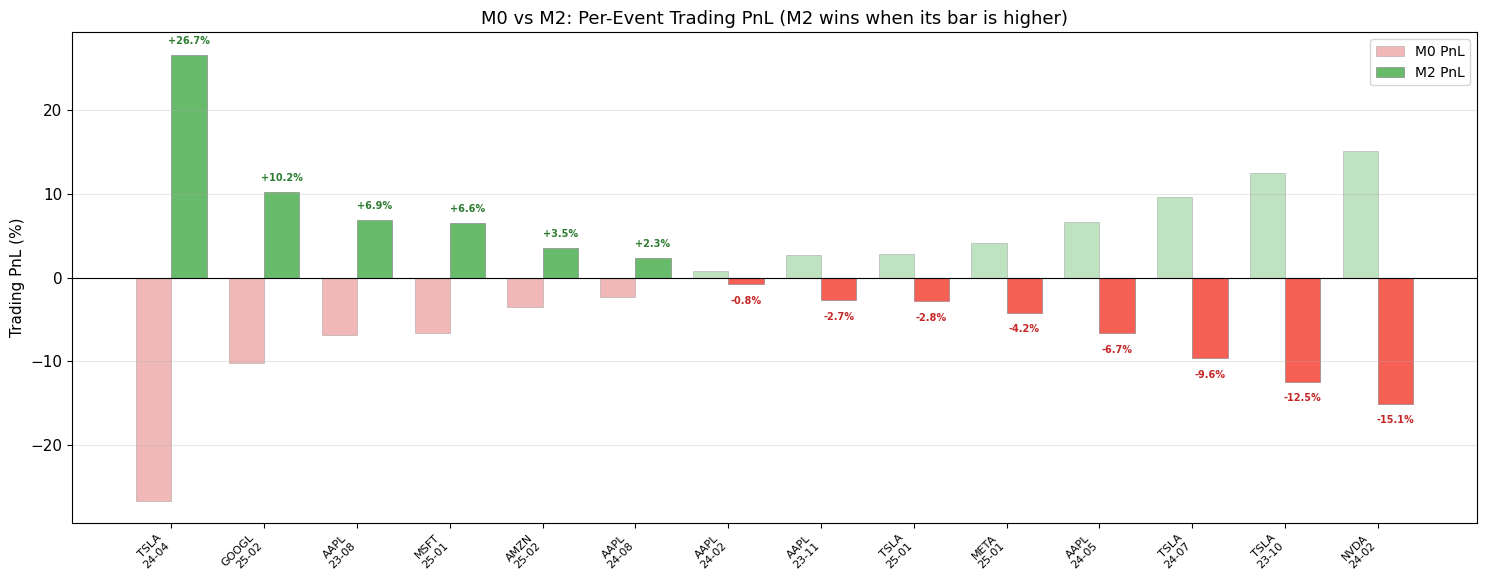

On these 14 disagreement events:
  M0 total PnL: -1.8%
  M2 total PnL: +1.8%
  M2 edge: +3.6%


In [7]:
# Sort by M2 actual PnL (biggest profit first)
rdf_sorted = rdf[rdf['m2_edge'] != 0].copy()
rdf_sorted['m2_pnl_pct'] = rdf_sorted['m2_pnl'] * 100
rdf_sorted['m0_pnl_pct'] = rdf_sorted['m0_pnl'] * 100
rdf_sorted = rdf_sorted.sort_values('m2_pnl_pct', ascending=False)

fig, ax = plt.subplots(figsize=(15, 6))
x = np.arange(len(rdf_sorted))
width = 0.38

# M0 bars (behind, lighter)
m0_colors = ['#81C784' if p > 0 else '#E57373' for p in rdf_sorted['m0_pnl_pct']]
bars_m0 = ax.bar(x - width/2, rdf_sorted['m0_pnl_pct'], width,
                 color=m0_colors, alpha=0.5, edgecolor='gray', linewidth=0.5, label='M0 PnL')

# M2 bars (front, saturated)
m2_colors = ['#4CAF50' if p > 0 else '#F44336' for p in rdf_sorted['m2_pnl_pct']]
bars_m2 = ax.bar(x + width/2, rdf_sorted['m2_pnl_pct'], width,
                 color=m2_colors, alpha=0.85, edgecolor='gray', linewidth=0.5, label='M2 PnL')

labels = [f"{r['ticker']}\n{r['earnings_date'].strftime('%y-%m')}" for _, r in rdf_sorted.iterrows()]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=8, rotation=45, ha='right')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Trading PnL (%)')
ax.set_title('M0 vs M2: Per-Event Trading PnL (M2 wins when its bar is higher)', fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Annotate M2 bars with PnL value
for i, (_, r) in enumerate(rdf_sorted.iterrows()):
    pnl = r['m2_pnl_pct']
    offset_y = 8 if pnl >= 0 else -14
    ax.annotate(f"{pnl:+.1f}%", (i + width/2, pnl),
                textcoords='offset points', xytext=(0, offset_y),
                ha='center', fontsize=7, fontweight='bold',
                color='#2E7D32' if pnl >= 0 else '#C62828')

plt.tight_layout()
plt.savefig('../outputs/m2_pnl_attribution.png', dpi=150, bbox_inches='tight')
plt.show()

total_m2 = rdf_sorted['m2_pnl_pct'].sum()
total_m0 = rdf_sorted['m0_pnl_pct'].sum()
print(f'On these {len(rdf_sorted)} disagreement events:')
print(f'  M0 total PnL: {total_m0:+.1f}%')
print(f'  M2 total PnL: {total_m2:+.1f}%')
print(f'  M2 edge: {total_m2 - total_m0:+.1f}%')

## 7. The Pattern: "Beat But Drop"

M2's victories share a common theme: companies that **beat earnings expectations** but had **unusually high pre-earnings sentiment** — and then the stock **dropped** anyway. Let's visualize this pattern.

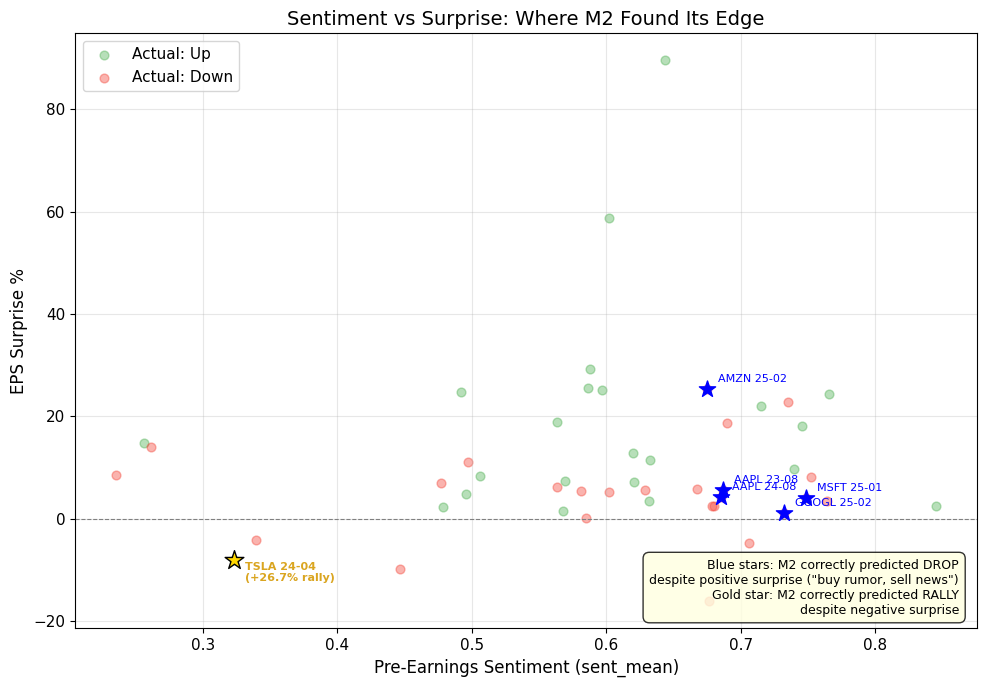

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

# All test events
up = rdf[rdf['target'] == 1]
down = rdf[rdf['target'] == 0]
ax.scatter(up['sent_mean'], up['surprise_pct'], c='#4CAF50', alpha=0.4, s=40, label='Actual: Up')
ax.scatter(down['sent_mean'], down['surprise_pct'], c='#F44336', alpha=0.4, s=40, label='Actual: Down')

# Highlight M2 unique wins
for _, evt in m2_unique_wins.iterrows():
    ax.scatter(evt['sent_mean'], evt['surprise_pct'], c='blue', s=150, marker='*', zorder=5)
    ax.annotate(f"{evt['ticker']} {evt['earnings_date'].strftime('%y-%m')}",
                (evt['sent_mean'], evt['surprise_pct']),
                textcoords='offset points', xytext=(8, 5), fontsize=8, color='blue')

# Highlight TSLA 2024-04-23 (biggest win, different direction)
tsla = rdf[(rdf['ticker'] == 'TSLA') & (rdf['earnings_date'] == '2024-04-23')]
if not tsla.empty:
    t = tsla.iloc[0]
    ax.scatter(t['sent_mean'], t['surprise_pct'], c='gold', s=200, marker='*', zorder=5, edgecolors='black')
    ax.annotate(f"TSLA 24-04\n(+26.7% rally)",
                (t['sent_mean'], t['surprise_pct']),
                textcoords='offset points', xytext=(8, -15), fontsize=8, color='goldenrod', fontweight='bold')

ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xlabel('Pre-Earnings Sentiment (sent_mean)', fontsize=12)
ax.set_ylabel('EPS Surprise %', fontsize=12)
ax.set_title('Sentiment vs Surprise: Where M2 Found Its Edge', fontsize=14)
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

# Add annotation box
ax.text(0.98, 0.02, 'Blue stars: M2 correctly predicted DROP\ndespite positive surprise ("buy rumor, sell news")\n'
        'Gold star: M2 correctly predicted RALLY\ndespite negative surprise',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('../outputs/m2_sentiment_vs_surprise.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Summary

### M2's 6 Victories over M0

**5 "Beat But Drop" events** (high sentiment + positive surprise → stock dropped):
- AAPL 2023-08, AAPL 2024-08, MSFT 2025-01, GOOGL 2025-02, AMZN 2025-02
- Common pattern: pre-earnings sentiment was very high (0.67-0.75), EPS beat expectations (+1% to +25%), but the stock dropped (-2% to -10%) — classic "buy the rumor, sell the news"
- M2 learned that high pre-earnings sentiment is a contrarian sell signal

**1 "Miss But Rally" event:**
- TSLA 2024-04: missed by -8.1% but rallied +26.7%
- This single event accounts for the majority of M2's PnL edge (+53.4% swing vs M0)

### M2's 8 Failures vs M0

The sentiment-based contrarian signal also misfired in 8 events where it incorrectly overrode M0's correct prediction. The net result was still positive for M2's trading returns because the victories involved larger price moves than the failures.

### Key Insight for M3

The "buy the rumor, sell the news" pattern is strongest when **system-wide** AI hype is high, not just company-specific. M3's cross-company spillover features could help distinguish:
- Company with high sentiment in a **generally hyped market** → likely to drop (priced in)
- Company with high sentiment but **peers have low/negative sentiment** → may still have upside (company-specific good news)